To install it, in the folder run pip install .

# Helper Submodule

In [1]:
import pyfluor.helper as helper
%matplotlib widget
import matplotlib.pyplot as plt

#### Line lists availables

In [2]:
helper.print_available_linelist_inventory()

Default available for fluorescence:
  - CN 12C14N
  - CN 12C15N
  - CN 13C14N
Comment: for the fluorescence modeling you could also provide your own line list

Available for line plotting:
  - [mol] CN 12C14N
  - [mol] CN 12C15N
  - [mol] CN 13C14N
  - [mol] NEOWISE (C2, C3, NH, CH)
  - [atom] Al
  - [atom] Ar
  - [atom] As
  - [atom] B
  - [atom] Be
  - [atom] Br
  - [atom] C
  - [atom] Ca
  - [atom] Cl
  - [atom] Co
  - [atom] Cr
  - [atom] Cu
  - [atom] F
  - [atom] Fe
  - [atom] Ga
  - [atom] Ge
  - [atom] H
  - [atom] He
  - [atom] K
  - [atom] Kr
  - [atom] Li
  - [atom] Mg
  - [atom] Mn
  - [atom] N
  - [atom] Na
  - [atom] Ne
  - [atom] Ni
  - [atom] O
  - [atom] P
  - [atom] Rb
  - [atom] S
  - [atom] Sc
  - [atom] Se
  - [atom] Si
  - [atom] Sr
  - [atom] Ti
  - [atom] V
  - [atom] Y
  - [atom] zinc_lines_air


CN lines from: Brooke et. al. 2014 and Sneden et. al. 2014
Neowise lines from: Cambianica et. al. 2021
Atomic lines from: NIST Atomic Spectra Database (Kramida et. al. 2020), notice that this lists are not the complete NIST list, just and extract from their tables.

#### Plot different linelists availables

In [ ]:
lines_cn_12 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C14N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_12 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C14N",
    upper_state="A",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_13 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="13C14N",
    upper_state="A",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_15 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C15N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_neowise_C2 = helper.get_linelist_wavelengths_vacuum(
    species='C2',
    n_lines=100)
lines_neowise_NH2 = helper.get_linelist_wavelengths_vacuum(
    species='NH2',
    n_lines=100)
lines_neowise_C3 = helper.get_linelist_wavelengths_vacuum(
    species='C3',
    n_lines=100)
lines_neowise_CH = helper.get_linelist_wavelengths_vacuum(
    species='CH',
    n_lines=100)

lines_atomic_iron = helper.get_linelist_wavelengths_vacuum(
    species='Fe',
    n_lines=100)
lines_atomic_nickel = helper.get_linelist_wavelengths_vacuum(
    species='Ni',
    n_lines=100)
lines_atomic_cobalt = helper.get_linelist_wavelengths_vacuum(
    species='Co',
    n_lines=100)

CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).


# Lets upload an spectrum
if the table does not have units enter none in units_row

In [ ]:
night = '20250924'
fibre = 'A'

spectra = helper.load_spectrum(dir_path='Output_spectras', night=night, fibre=fibre, header_row=1, units_row=0, data_start=3)

spectra.pprint()

       WAVE              FLUX_STACK       ...     WAVENUMBER    
     Angstrom      erg / (Angstrom s cm2) ...       1 / cm      
------------------ ---------------------- ... ------------------
3772.3021197818316                    nan ...  26509.01142716094
  3772.30841109057                    nan ...   26508.9672164663
   3772.3147024098                    nan ... 26508.923005845405
3772.3209937395227                    nan ... 26508.878795298235
 3772.327285079737                    nan ... 26508.834584824806
3772.3335764304447                    nan ... 26508.790374425105
3772.3398677916457                    nan ... 26508.746164099128
3772.3461591633372                    nan ...   26508.7019538469
 3772.352450545522                    nan ... 26508.657743668395
               ...                    ... ...                ...
 7900.474405631213                    nan ... 12657.467750129423
7900.4875817563925                    nan ... 12657.446640498174
7900.5007579035455       

#### lets plot some lines and the spec

In [5]:
%matplotlib widget
from matplotlib import pyplot as plt

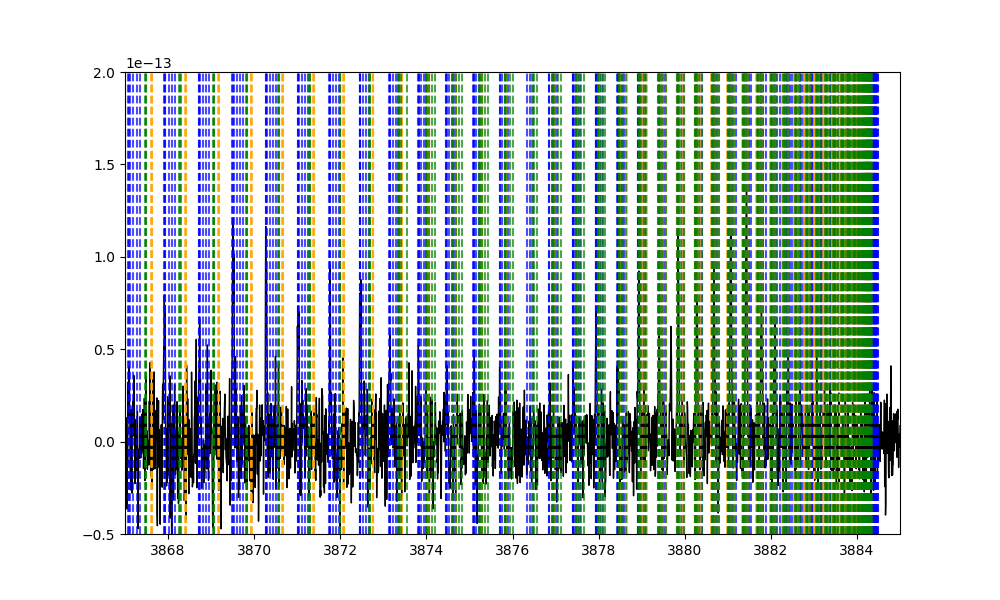

In [6]:

plt.figure(figsize=(10, 6))
plt.plot(spectra['WAVE'], spectra['FLUX_STACK'], label='Spectrum', color='black', lw=1)
for i in lines_cn_12:
    plt.axvline(i, color='blue', linestyle='--', alpha=0.7, label='CN 12C14N' if i == lines_cn_12[0] else "")
for i in lines_cn_13:
    plt.axvline(i, color='orange', linestyle='--', alpha=0.7, label='CN 13C14N' if i == lines_cn_13[0] else "")
for i in lines_cn_15:
    plt.axvline(i, color='green', linestyle='--', alpha=0.7, label='CN 12C15N' if i == lines_cn_15[0] else "")
# for i in lines_atomic_iron:
#     plt.axvline(i, color='red', linestyle=':', alpha=0.7, label='Fe I' if i == lines_atomic_iron[0] else "")
plt.xlim(3867, 3885)
plt.ylim(-5e-14, 2e-13)
plt.show()

#### now lets get the mean values for that nigth the most important in this case is r_au as is going to be used for the incident solar flux calculation at the comet position you can replace this by having r and rdot values

load_ephemeris_summary allows you to create a dict for different with the mean values for the comet and get_ephemeris_for_nights allows you to filter one night dict from all the nights

In [7]:
from pathlib import Path
path = Path('Ephemeris/ephemeris_means_by_observation.csv')
#you could use the key_column kwarg to set another column as key default is 'date_obs', if is not there schange it as neede
ephemeris_all = helper.load_ephemeris_summary(path)
ephemeris_all
mean_values = helper.get_ephemeris_for_night(ephemeris_all, night)

mean_values

{'date_obs': 20250924,
 'n_exposures': 3,
 'ephemeris_file': 'Ephemeris/horizons_results_20250924.txt',
 'mean_jd_ut': 2460943.4863425926,
 'mean_dra_cosdec_arcsec_per_hr': -73.40633333333334,
 'mean_ddec_arcsec_per_hr': 18.190626666666663,
 'mean_t_mag': 15.507666666666665,
 'mean_r_au': 1.8492717459746668,
 'mean_rdot_km_s': -42.52747686666666,
 'mean_delta_au': 2.5189498192818296,
 'mean_deldot_km_s': -4.3657516,
 'mean_ra_deg': 219.31738194861111,
 'mean_dec_deg': -11.631675350000002,
 'mean_MJD': 60942.986342592594}

#### Remember the previous cell is optional, if you want to have r, delta, rdot, deltadot, or any other usefull value you can create your own dict, list, etc... with that values

# Now lets get the values of the solar irradiance that night

## 2 Options here:
 1) Load pre-calculated solar fluxes at the comet distance (I previously fitted a little delta lambda up the solar velocity to match the solar lines in the comet spectrum, so I used that solar irradiance here)
 2) Load the solar flux at 1 au (Kurucz)and shift it according to the comet from your machine or using the one stored in the package, for this is important to be concistent with the units, the default kurucz in the module is in u.AA and u.erg / (u.s * u.cm**2 * u.AA)


##### Option 1

In [ ]:
# For this option there are kwargs to load different column names, name formats, etc...

solar = helper.load_pumping_file(night=night, directory='Pumping_files', scale_by_r_au=mean_values['mean_r_au'])

##### Option 2

In [9]:
import pandas as pd
import numpy as np

from astropy import constants as c
from astropy import units as u
# Option 2a: load from a local file shift the wavelength accordingly by the rdot andscale with the distance:
# solar = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux/rdot**2})

#Option 2b: load from the preloaded file in the package

# Another option is using the preloaded kurucz in the helper
kurucz = helper.open_kurucz_irradiance()
wave = kurucz['WAVE']
flux = kurucz['FLUX']

beta   =  mean_values['mean_rdot_km_s']/ c.c.to(u.km / u.s).value
factor = np.sqrt((1.0 + beta) / (1.0 - beta))

wave_shifted = wave * factor
solar = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux/mean_values['mean_r_au']**2})

This are the most important functions iin this submodule, there are another ones, but mainly to find paths, list files, etc...

### The modeling submodule has a lot of good functions I recomend to check it out, however almost all of them are used with the fluorescence submodule so we are going to focus there.

# Now lets create a model using the FluorescenceModel class

In [10]:
from pyfluor.fluorescence import FluorescenceModel

In [ ]:
from astropy.io import fits



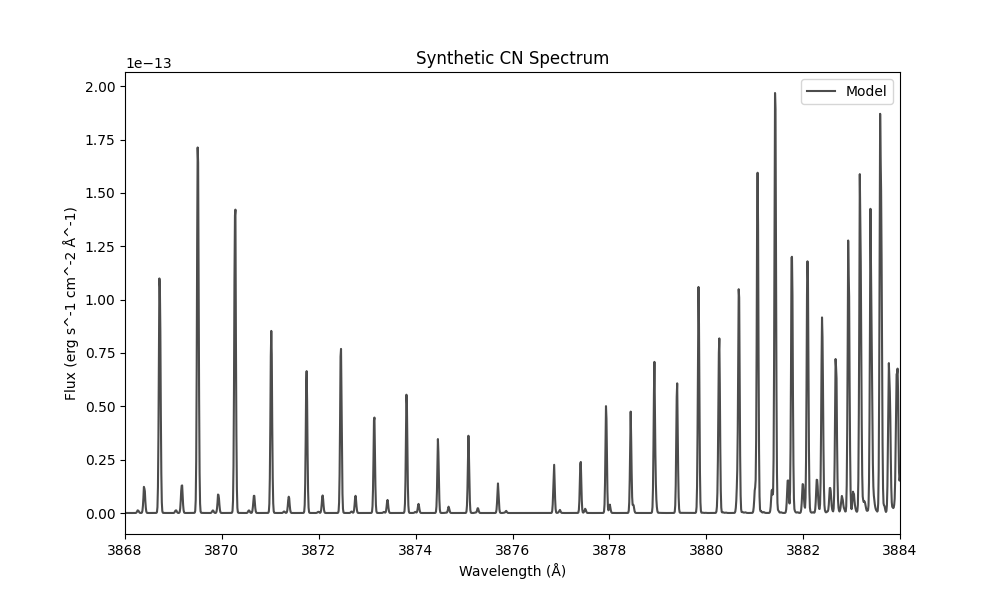

In [17]:
# wave_col, flux_col, error_col, continuum_col can be changed to your data coluns names omega 
# is the solid angle in sr of the observation default is assuming circular of radius 0.5 arcsec
# default line list 12C14N including B-X 00 and A-X delta v=1 (violet and red systems)
col = {iso: 12.1 -   i for i, iso in enumerate(['12C14N', '13C14N', '12C15N'])}
model = FluorescenceModel(
    data=spectra,  #this is just used on the fitting stage but let's attach it here
    pumping=solar,  #solar pumping spectrum
    window = (3868.0, 3884.0), #wavelength range to be modeled and fitted
    lsf=None,  #no pre computed lsf function provided, None it will be set then other params
    lsf_method="Gauss_Lorentz",  #method to use to compute the lsf if no lsf function is provided
    A_min=1e4,  #minimum Einstein A coefficient to consider form the line list
    name=f'CN_Model {night}',  #name of the model
    sigma_G=0.015, #initial parameter for the Gaussian sigma
    fwhm_L=0.005, #initial parameter for the Lorentzian FWHM
    ratio = 0.95,  #initial parameter for the Gauss-Lorentz ratio
    logN_by_iso=col,  #initial parameter for the column density log10 value
    v_kms=0.0,  #initial parameter for the velocity shift in km/s (in case small shifts are needed)
    T=300.0,  #initial parameter for the rotational temperature in K
    logQ=-2,  #initial parameter for the log10 of the collisions rate in s^-1),
    isotopologues=['12C14N', '13C14N', '12C15N']  #include the isotopologues to model
)



plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic CN Spectrum')
plt.legend()
plt.show()

When creating the model there are multiple useful atribute so check the doc

### I recommend to be concistent with the lsf_method choosen and the parameters given to the model, all the codes will read first lsf_method

Gauss_Lorentz uses sigma_G, sigma_L and ratio (between gauss and lorentz)
Gauss uses only sigma
2Gauss uses sigma_1, sigma_2 and ratio (between gauss and gauss2)

if one is choosen please do not provide parameters for the other lsf methods, or set them to None. It should work even if you provide all the parameters but its better to avoid confusion or bugs.

one can update parameters and re calculate the model easily, **update_model()** function
is needed after changing any parameter to update the model, parameters can be given also to update_model function directly, and that will overwrite the current ones
this step is needed as it also need to recalculate the model

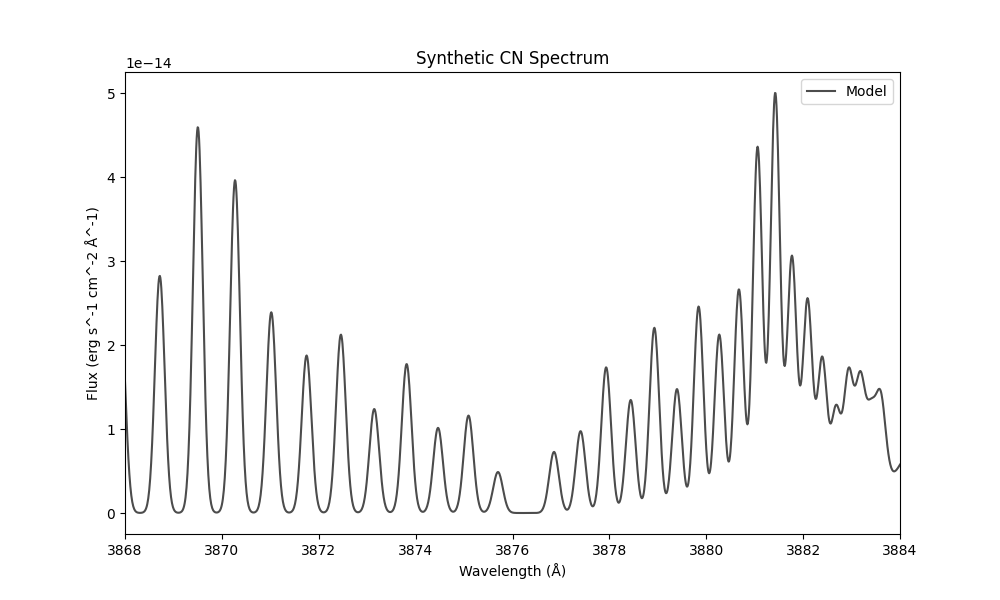

In [12]:
model.lsf_method = 'Gauss'
model.sigma = 0.1
model.logQ = -1
model.update_model()

plt.figure(figsize=(10, 6))
plt.plot(model.model_wave, model.best_model, color='k', alpha=0.7, label='Model')
plt.xlabel('Wavelength (Å)')
plt.xlim(model.window)
plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
plt.title('Synthetic CN Spectrum')
plt.legend()
plt.show()

# Now lets do 2 types of fitting, one with lsf fixed and one with lsf free to vary

For the calculations of J_nu it is assumed a delta de dirac, no doppler broadening. it does not change significantly, if the physical line profile is narrow. It is not included for fitting as the matrix to be computed is not trivial so the computationtime will increase a lot if is calculated in each step of mcmc.

Pleae increase the nwalwers and steos, now is low just for testing purposes

In [13]:
from pyfluor.fluorescence import FluorescenceModel

priors = {
    'logN': (5, 20),          # log10 column density [cm^-2]
    'logQ': (-5, -1),         # log10 collision rate [s^-1]
    'T': (10, 400),         # kinetic temperature [K]
}
#initialize a model with a fixed lsf
model = FluorescenceModel(
    data=spectra, 
    window = (3866.0, 3884.0), 
    pumping=solar, 
    lsf=None,  
    lsf_method="Gauss",  
    A_min=1e4, 
    name=f'CN_Model {night}', 
    sigma = 0.01,
    logN=12.0, 
    v_kms=0.0,  
    T=300.0, 
    logQ=-2.0,
    isotopologues=['12C14N'],
)


Number of iterations: 6000


100%|██████████| 200/200 [00:25<00:00,  7.80it/s]


##################################################
*** Best fit (no pruning) ***
logN: 11.4969
logQ: -1.00461
T: 222.785
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.4135
logN: 11.4972 +/- 0.0088  [11.4888, 11.5064]
logQ: -1.0317 +/- 0.0323  [-1.0730, -1.0084]
T: 221.1360 +/- 6.0277  [215.0676, 227.1231]


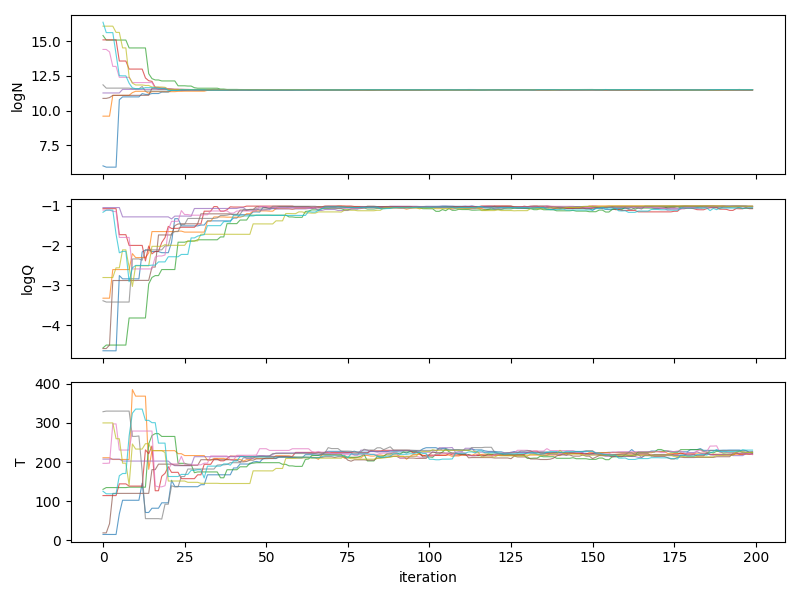

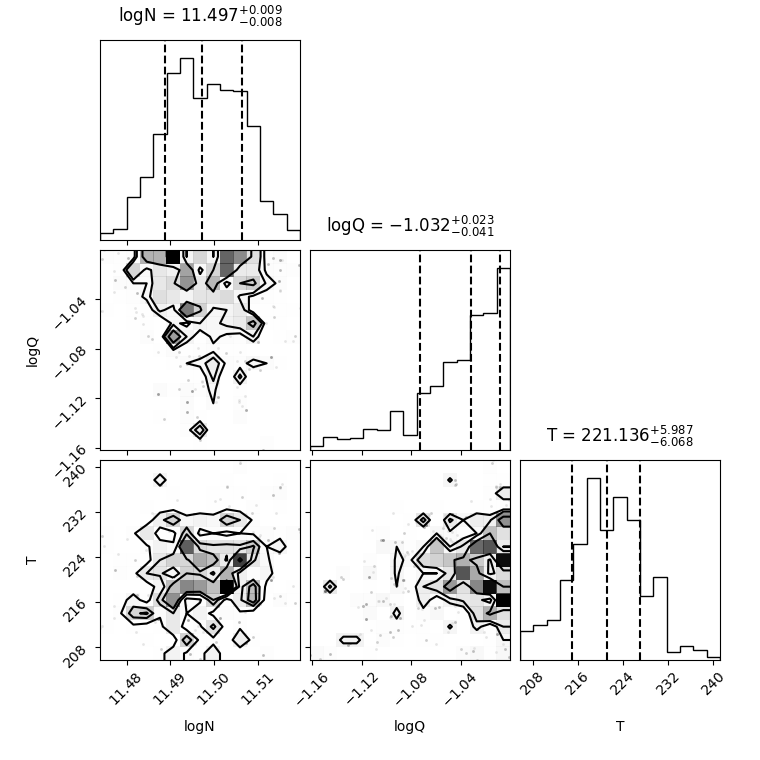

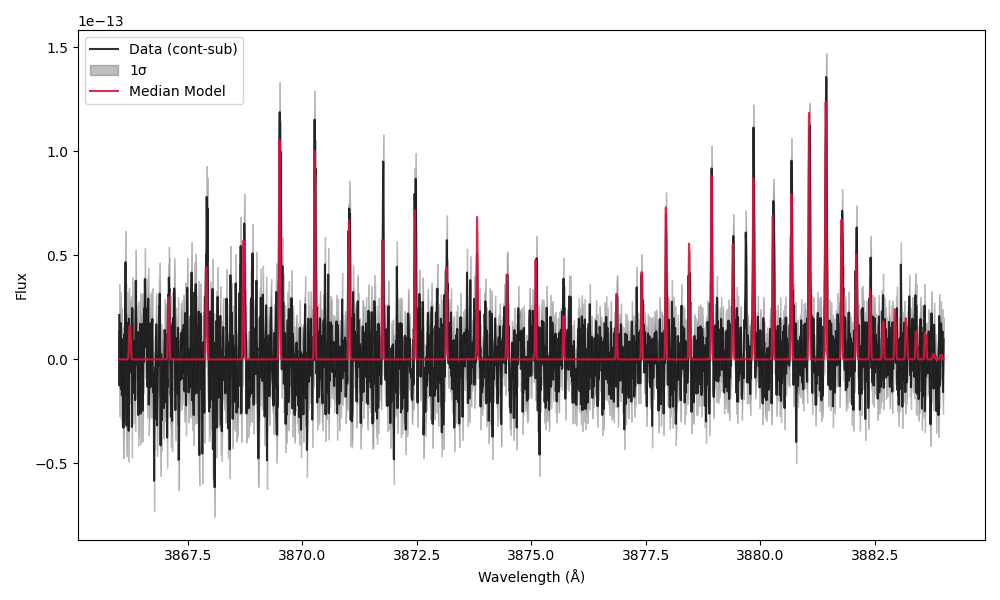

{'param_keys': ['logN', 'logQ', 'T'],
 'median_params': {'logN': 11.49720986149124,
  'logQ': -1.0316584694984727,
  'T': 221.13596204535992},
 'up_errors_params': {'logN': 0.009213341098728733,
  'logQ': 0.023261973355105825,
  'T': 5.98709511996833},
 'low_errors_params': {'logN': 0.008448706036585207,
  'logQ': 0.04136592146046225,
  'T': 6.068330489271148},
 'samples_pruned': array([[ 11.50286881,  -1.01170613, 236.45879355],
        [ 11.50124778,  -1.04552287, 215.92253007],
        [ 11.48991414,  -1.0699128 , 212.94046389],
        ...,
        [ 11.48479078,  -1.01571415, 226.83190797],
        [ 11.49392563,  -1.00906745, 224.22518216],
        [ 11.50521752,  -1.0525208 , 230.39624318]], shape=(990, 3)),
 'lnprob_pruned': array([84331.72571841, 84332.69718661, 84331.46775315, 84332.69274554,
        84333.36592237, 84333.15057192, 84332.05637454, 84332.52743448,
        84332.35674023, 84330.70064409, 84331.72571841, 84332.67407523,
        84331.215875  , 84332.69274554, 84

In [14]:
model.fit_mcmc(data = spectra,
               window=model.window,
               pumping=solar,
               nwalkers=10,
               nsteps=200,
               priors=priors,
               lsf=model.lsf,
               make_plots=True,
               progress=True,
               A_min=1e5,
               a=3,
               threads=4,
               fig_file='Example_plots/example1',
               include_rotations=True
               ) 
# include rotations needs to set False to exclude rotational collisions

In [16]:
"""
Same as before, but UPDATED plotting:

- For multi-isotopologue models, plot ALL isotopologue components in the SAME figure
  (optionally also plot the total/sum curve).

This script does NOT change your model code; it only changes the test/plot code.
"""

import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt

from pyfluor.fluorescence import FluorescenceModel  # adjust
from pyfluor import modeling  # adjust


# ------------------------------------------------------------
# 0) Fake generators
# ------------------------------------------------------------
def make_fake_transitions(
    *,
    iso: str,
    n_lines: int,
    lam_min: float,
    lam_max: float,
    A_range=(1e6, 5e7),
    seed: int = 0,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    lam = np.sort(rng.uniform(lam_min, lam_max, size=n_lines)).astype(float)
    Aul = rng.uniform(A_range[0], A_range[1], size=n_lines).astype(float)

    n_upper_levels = max(3, n_lines // 3)
    n_lower_levels = max(3, n_lines // 3)

    upper_levels = [f"{iso}|U{i}" for i in range(n_upper_levels)]
    lower_levels = [f"{iso}|L{i}" for i in range(n_lower_levels)]

    upper_id = rng.choice(upper_levels, size=n_lines, replace=True)
    lower_id = rng.choice(lower_levels, size=n_lines, replace=True)

    g_upper = (rng.integers(0, 10, size=n_lines).astype(float) * 2.0 + 1.0)
    g_lower = (rng.integers(0, 10, size=n_lines).astype(float) * 2.0 + 1.0)

    E_cm1 = 1.0 / (lam * 1e-8)

    return pd.DataFrame(
        {
            "lambda_vac_A": lam,
            "A_ul": Aul,
            "upper_id": upper_id.astype(str),
            "lower_id": lower_id.astype(str),
            "g_upper": g_upper,
            "g_lower": g_lower,
            "E_cm1": E_cm1,
        }
    )


def make_fake_pumping(*, lam_min: float, lam_max: float, dlam: float = 0.02) -> pd.DataFrame:
    wave = np.arange(lam_min, lam_max + dlam, dlam, dtype=float)
    flux = 1e-12 * (1.0 + 0.2 * np.sin((wave - lam_min) / 3.0) + 0.1 * np.cos((wave - lam_min) / 11.0))
    return pd.DataFrame({"WAVE": wave, "FLUX": flux})


def make_fake_observed_data(
    *,
    wave: np.ndarray,
    true_flux: np.ndarray,
    snr: float = 50.0,
    cont_level: float = 0.0,
    seed: int = 0,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    scale = np.max(np.abs(true_flux)) if np.max(np.abs(true_flux)) > 0 else 1.0
    sigma = scale / snr
    noise = rng.normal(0.0, sigma, size=wave.size)
    cont = np.full_like(wave, cont_level, dtype=float)
    return pd.DataFrame(
        {
            "WAVE": wave,
            "FLUX_STACK": true_flux + cont + noise,
            "ERR_STACK": np.full_like(wave, sigma, dtype=float),
            "CONTINUUM": cont,
        }
    )


# ------------------------------------------------------------
# 1) Spectrum extraction for per-iso components
# ------------------------------------------------------------
def get_per_iso_spectra(model, *, use_median_if_available: bool = True):
    """
    Returns:
      wave, total_spec, spec_by_iso

    Requires:
      model.lines_by_iso, model.g_en_by_iso (built in _synthesize_model)
    """
    wave = np.asarray(model.model_wave, float)
    if wave.size == 0:
        raise ValueError("model.model_wave is empty")

    if use_median_if_available and getattr(model, "median_model", None) is not None:
        total_spec = np.asarray(model.median_model, float)
    else:
        total_spec = np.asarray(model.best_model, float)

    iso_list = [model.isotopologues] if isinstance(model.isotopologues, str) else list(model.isotopologues)

    if getattr(model, "lines_by_iso", None) is None or getattr(model, "g_en_by_iso", None) is None:
        raise ValueError("Missing per-iso caches (lines_by_iso / g_en_by_iso).")

    omega = np.pi * (0.5 * np.pi / (180.0 * 3600.0)) ** 2

    spec_by_iso = {}
    for iso in iso_list:
        lines = model.lines_by_iso[iso]
        g_en = np.asarray(model.g_en_by_iso[iso], float)

        # logN per iso
        if len(iso_list) == 1:
            logN_i = float(model.logN)
        else:
            if getattr(model, "logN_by_iso", None) and iso in model.logN_by_iso:
                logN_i = float(model.logN_by_iso[iso])
            else:
                if model.logN is None:
                    raise ValueError("Multi-iso: set model.logN_by_iso or a common model.logN.")
                logN_i = float(model.logN)

        grid, spec_i = modeling.synth_spectrum_from_lines(
            lines,
            g_line_energy=g_en,
            lam_min=float(wave.min()),
            lam_max=float(wave.max()),
            lam_col="Wave_vac_AA",
            N_col_cm2=10.0 ** logN_i,
            Omega_sr=omega,
            grid=wave,
            lsf=model.lsf,
            v_shift_kms=float(model.v_kms or 0.0),
            dlam_shift_A=float(model.dlam or 0.0),
        )
        if np.asarray(grid).shape != wave.shape:
            spec_i = np.interp(wave, np.asarray(grid, float), np.asarray(spec_i, float))

        spec_by_iso[iso] = np.asarray(spec_i, float)

    return wave, total_spec, spec_by_iso


# ------------------------------------------------------------
# 2) Plot helpers (single plot for all iso components)
# ------------------------------------------------------------
def plot_model_vs_data_total_and_components(
    model,
    data: pd.DataFrame,
    *,
    title: str = "",
    cont_subtract: bool = True,
    show_total: bool = True,
    show_components: bool = True,
):
    x = np.asarray(data["WAVE"], float)
    y = np.asarray(data["FLUX_STACK"], float)
    e = np.asarray(data["ERR_STACK"], float)
    c = np.asarray(data["CONTINUUM"], float)
    y_plot = y - c if cont_subtract else y

    wave, total_spec, spec_by_iso = get_per_iso_spectra(model)

    plt.figure(figsize=(11, 4))
    plt.plot(x, y_plot, lw=1.0, label="Data (cont-sub)" if cont_subtract else "Data")
    plt.fill_between(x, y_plot - e, y_plot + e, alpha=0.25, label="1σ")

    # total curve
    if show_total:
        m_total = np.interp(x, wave, total_spec)
        plt.plot(x, m_total, lw=2.0, label="Model (total)")

    # component curves (all on same axes)
    if show_components and len(spec_by_iso) > 1:
        for iso, spec_i in spec_by_iso.items():
            m_i = np.interp(x, wave, spec_i)
            plt.plot(x, m_i, lw=1.2, ls="--", label=f"{iso} component")

    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux")
    if title:
        plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 3) One runner that can do ANY combination
# ------------------------------------------------------------
def run_case(
    *,
    case_name: str,
    isotopologues,
    use_defaults: bool,
    pumping,
    window,
    systems=None,
    user_linelists=None,
    do_fit: bool = True,
    seed: int = 0,
):
    print("\n" + "=" * 80)
    print(f"CASE: {case_name}")
    print(f"  isotopologues = {isotopologues}")
    print(f"  use_defaults  = {use_defaults}")
    print(f"  systems       = {systems}")

    init_kwargs = dict(
        pumping=pumping,
        window=window,
        isotopologues=isotopologues,
        systems=systems,
        lsf_method="Gauss",
        sigma=0.02,
        logQ=-3.2,
        T=300.0,
        v_kms=0.0,
        dlam=0.0,
        A_min=1e6
    )

    # Column densities
    if isinstance(isotopologues, str):
        init_kwargs["logN"] = 11.1
    else:
        init_kwargs["logN_by_iso"] = {iso: 11.1 - 0.4 * i for i, iso in enumerate(isotopologues)}
        init_kwargs["logN"] = 11.1  # optional common fallback

    init_kwargs["linelists"] = None if use_defaults else user_linelists

    # ---- build model ----
    model = FluorescenceModel(**init_kwargs)

    # ---- make fake observed data from the (total) model ----
    data = make_fake_observed_data(
        wave=np.asarray(model.model_wave, float),
        true_flux=np.asarray(model.best_model, float),
        snr=60.0,
        seed=seed,
    )

    # PRE-FIT plot: total + all components on ONE figure
    plot_model_vs_data_total_and_components(
        model,
        data,
        title=f"{case_name} (pre-fit)",
        show_total=True,
        show_components=True,
    )

    if not do_fit:
        return model, None, data

    # ---- priors ----
    priors = {"logQ": (-5.0, -2.0), "T": (50.0, 1000.0), "sigma": (0.005, 0.05)}
    if isinstance(isotopologues, str):
        priors["logN"] = (9.0, 15.0)
    else:
        for iso in isotopologues:
            priors[f"logN_{iso}"] = (9.0, 15.0)

    fit_kwargs = dict(
        data=data,
        window=window,
        pumping=pumping,
        isotopologues=isotopologues,
        systems=systems,
        linelists=None if use_defaults else user_linelists,
        priors=priors,
        nwalkers=20,
        nsteps=250,
        make_plots=False,
        progress=True,
        A_min=1e6,
        fig_file=f"test_{case_name.replace(' ', '_')}",
    )

    res = model.fit_mcmc(**fit_kwargs)

    # POST-FIT plot: total + all components on ONE figure
    plot_model_vs_data_total_and_components(
        model,
        data,
        title=f"{case_name} (after fit)",
        show_total=True,
        show_components=True,
    )

    print("  fitted medians:", res.get("median_params", {}))
    return model, res, data


In [17]:

# ------------------------------------------------------------
# 3) Define isotopologues + build user-provided linelists
# ------------------------------------------------------------
window = (3850.0, 3900.0)
pumping = make_fake_pumping(lam_min=window[0] - 50, lam_max=window[1] + 50, dlam=0.02)

iso1 = "12C14N"
iso2 = "12C15N"
iso3 = "13C14N"

user_ll_1 = make_fake_transitions(iso=iso1, n_lines=80, lam_min=window[0], lam_max=window[1], seed=1)

user_ll_2 = {
    iso1: make_fake_transitions(iso=iso1, n_lines=80, lam_min=window[0], lam_max=window[1], seed=1),
    iso2: make_fake_transitions(iso=iso2, n_lines=60, lam_min=window[0], lam_max=window[1], seed=2),
}

user_ll_3 = {
    iso1: make_fake_transitions(iso=iso1, n_lines=80, lam_min=window[0], lam_max=window[1], seed=1),
    iso2: make_fake_transitions(iso=iso2, n_lines=60, lam_min=window[0], lam_max=window[1], seed=2),
    iso3: make_fake_transitions(iso=iso3, n_lines=50, lam_min=window[0], lam_max=window[1], seed=3),
}

# systems combos (only meaningful for defaults)
# adjust labels to whatever you implemented, e.g. ["BX_00"], ["AX_dv1"], ["BX_00","AX_dv1"], None
systems_list = [None, ["BX_00"]]


CASE: DEFAULT single 12C14N systems=None
  isotopologues = 12C14N
  use_defaults  = True
  systems       = None


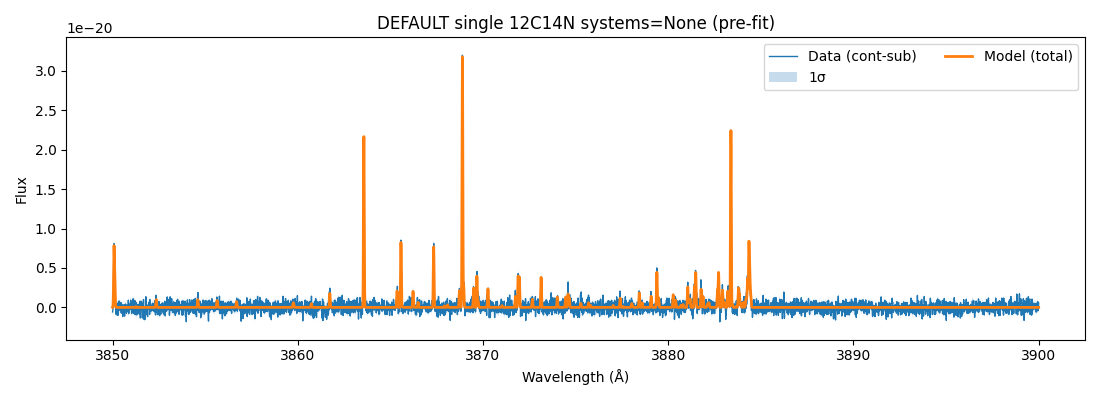

Number of iterations: 20000


100%|██████████| 250/250 [00:43<00:00,  5.76it/s]


##################################################
*** Best fit (no pruning) ***
logQ: -2.81669
T: 382.036
sigma: 0.031118
logN: 10.9412
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.3486
logQ: -3.3292 +/- 1.0179  [-4.4752, -2.4394]
T: 500.9008 +/- 292.6457  [214.6301, 799.9216]
sigma: 0.0329 +/- 0.0039  [0.0292, 0.0370]
logN: 10.9523 +/- 0.0331  [10.9187, 10.9850]


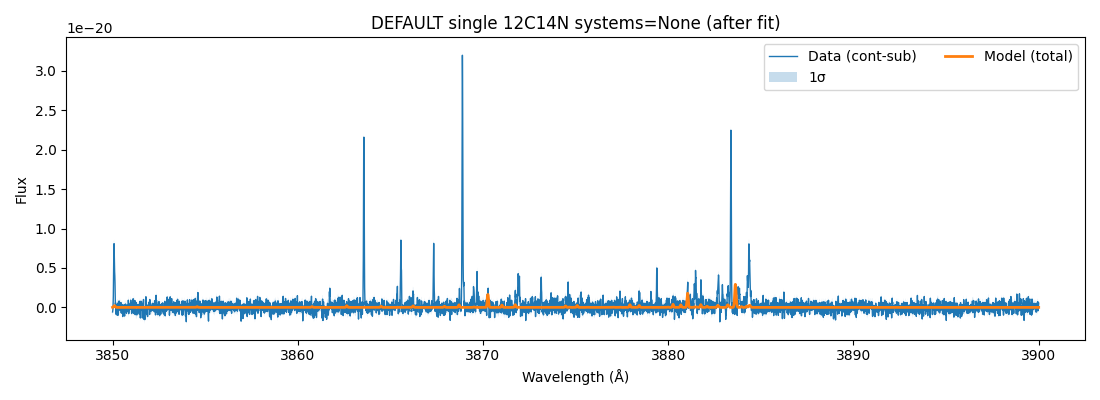

  fitted medians: {'logQ': -3.329244456696802, 'T': 500.90075562488846, 'sigma': 0.03286924646852965, 'logN': 10.952269424279956}


(<pyfluor.fluorescence.FluorescenceModel at 0x123003250>,
 {'param_keys': ['logQ', 'T', 'sigma', 'logN'],
  'median_params': {'logQ': -3.329244456696802,
   'T': 500.90075562488846,
   'sigma': 0.03286924646852965,
   'logN': 10.952269424279956},
  'up_errors_params': {'logQ': 0.8898847278687625,
   'T': 299.02081052686435,
   'sigma': 0.004089342098937972,
   'logN': 0.032759724841330495},
  'low_errors_params': {'logQ': 1.145995304773686,
   'T': 286.27063830687223,
   'sigma': 0.0036594246457754796,
   'logN': 0.03353930258791493},
  'samples_pruned': array([[-3.02660094e+00,  7.70705767e+02,  3.32414039e-02,
           1.09692415e+01],
         [-3.25108689e+00,  1.16702112e+02,  3.33778304e-02,
           1.09564882e+01],
         [-2.01789738e+00,  7.16544792e+02,  3.27636459e-02,
           1.09202768e+01],
         ...,
         [-3.90554090e+00,  2.66236933e+02,  3.09808405e-02,
           1.09211703e+01],
         [-2.72360256e+00,  7.99953757e+02,  4.14685187e-02,
          

In [18]:
run_case(
    case_name=f"DEFAULT single {iso1} systems={None}",
    isotopologues=iso1,
    use_defaults=True,
    pumping=pumping,
    window=window,
    systems=None,
    user_linelists=None,
    do_fit=True,
    seed=10,
)


CASE: DEFAULT single 12C14N systems=BX_00
  isotopologues = 12C14N
  use_defaults  = True
  systems       = ['BX_00']


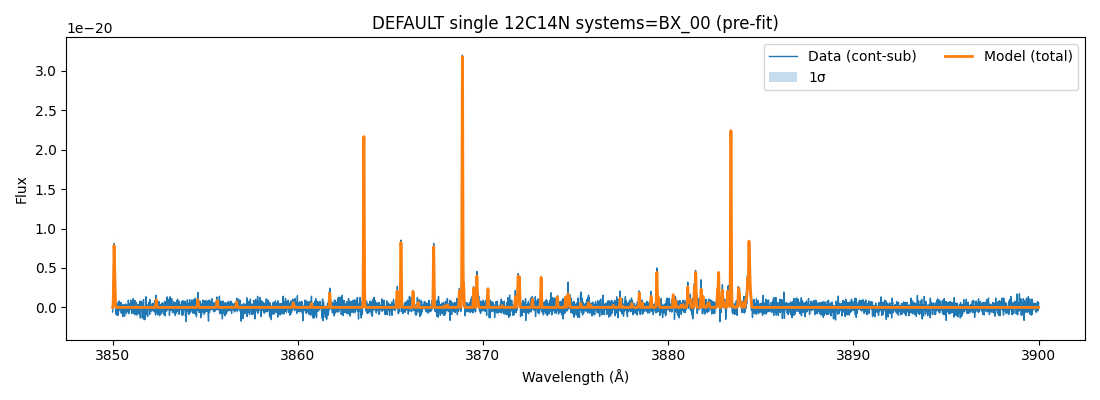

Number of iterations: 20000


100%|██████████| 250/250 [00:44<00:00,  5.68it/s]


##################################################
*** Best fit (no pruning) ***
logQ: -3.24652
T: 494.719
sigma: 0.0309812
logN: 10.9413
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.3516
logQ: -3.5951 +/- 0.9705  [-4.4807, -2.5398]
T: 486.1590 +/- 322.9413  [184.0454, 829.9281]
sigma: 0.0326 +/- 0.0043  [0.0284, 0.0371]
logN: 10.9509 +/- 0.0295  [10.9220, 10.9810]


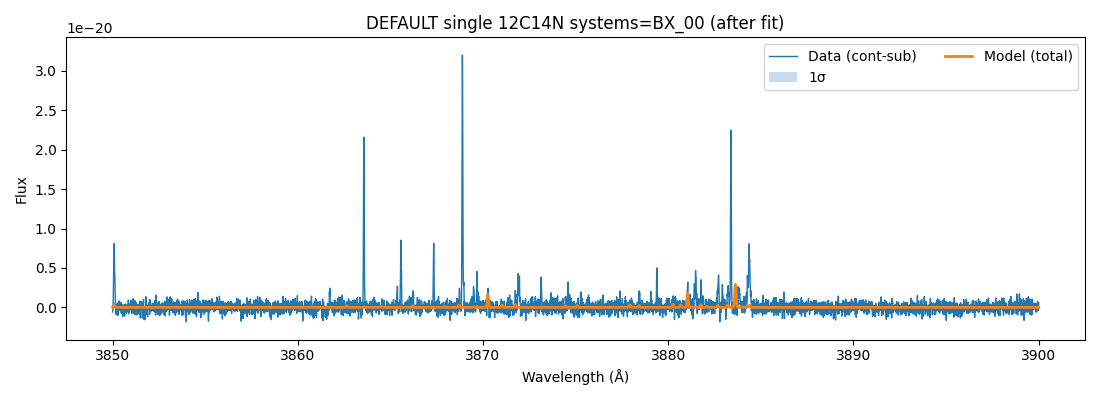

  fitted medians: {'logQ': -3.595085290889539, 'T': 486.1589594841195, 'sigma': 0.03263061962206244, 'logN': 10.950901843891295}


(<pyfluor.fluorescence.FluorescenceModel at 0x11a489e50>,
 {'param_keys': ['logQ', 'T', 'sigma', 'logN'],
  'median_params': {'logQ': -3.595085290889539,
   'T': 486.1589594841195,
   'sigma': 0.03263061962206244,
   'logN': 10.950901843891295},
  'up_errors_params': {'logQ': 1.0553202482720119,
   'T': 343.7691652195295,
   'sigma': 0.004458583332443027,
   'logN': 0.03008212991078807},
  'low_errors_params': {'logQ': 0.8856053586381529,
   'T': 302.1135341643458,
   'sigma': 0.00419246773733804,
   'logN': 0.028874716847585802},
  'samples_pruned': array([[-3.17575258e+00,  8.43860964e+02,  3.18765734e-02,
           1.09489602e+01],
         [-4.55780613e+00,  2.64786838e+02,  3.33107076e-02,
           1.09176597e+01],
         [-2.74424356e+00,  2.55706338e+02,  2.76652041e-02,
           1.09310525e+01],
         ...,
         [-2.17253901e+00,  3.82897840e+02,  3.28272685e-02,
           1.09831032e+01],
         [-3.36843054e+00,  5.51080611e+02,  3.03395058e-02,
           1.0

In [19]:
run_case(
    case_name=f"DEFAULT single {iso1} systems=BX_00",
    isotopologues=iso1,
    use_defaults=True,
    pumping=pumping,
    window=window,
    systems=["BX_00"],
    user_linelists=None,
    do_fit=True,
    seed=10,
)


CASE: DEFAULT two [12C14N,12C15N] systems=None
  isotopologues = ['12C14N', '12C15N']
  use_defaults  = True
  systems       = None


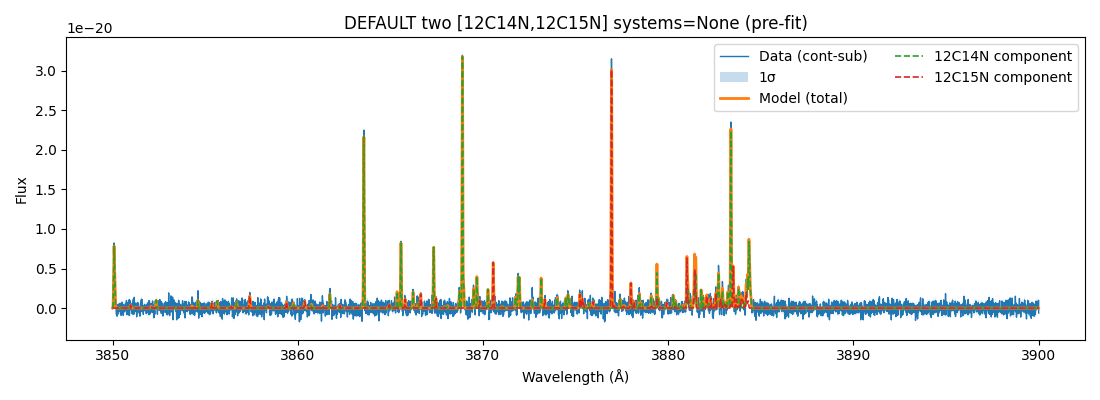

Number of iterations: 25000


100%|██████████| 250/250 [01:22<00:00,  3.02it/s]


##################################################
*** Best fit (no pruning) ***
logQ: -3.58702
T: 544.267
sigma: 0.0499837
logN_12C14N: 11.1195
logN_12C15N: 11.3568
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.31179999999999997
logQ: -3.6849 +/- 1.0562  [-4.5492, -2.4368]
T: 524.4116 +/- 281.2252  [259.6166, 822.0671]
sigma: 0.0499 +/- 0.0001  [0.0497, 0.0500]
logN_12C14N: 11.1277 +/- 0.0200  [11.1069, 11.1469]
logN_12C15N: 11.3530 +/- 0.0101  [11.3445, 11.3648]


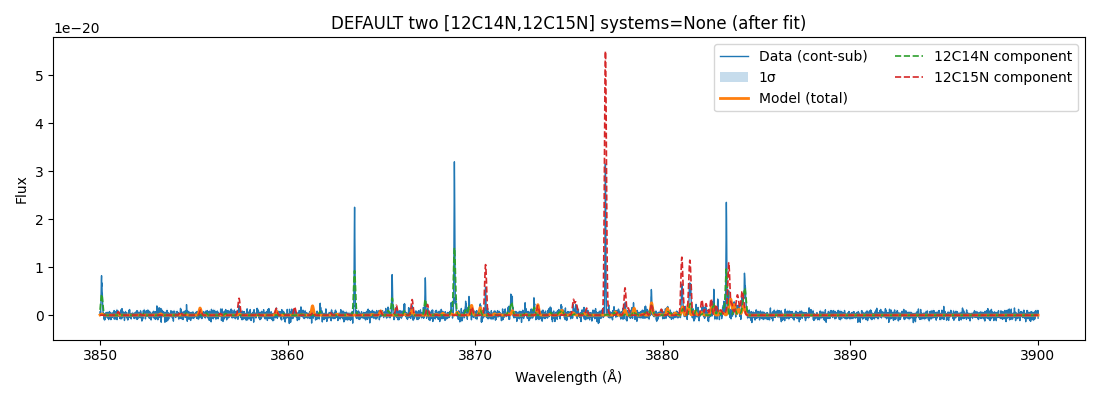

  fitted medians: {'logQ': -3.6849340793043273, 'T': 524.4115580679992, 'sigma': 0.049856975085008054, 'logN_12C14N': 11.12772902181062, 'logN_12C15N': 11.352991159272863}

CASE: DEFAULT two [12C14N,12C15N] systems=['BX_00']
  isotopologues = ['12C14N', '12C15N']
  use_defaults  = True
  systems       = ['BX_00']


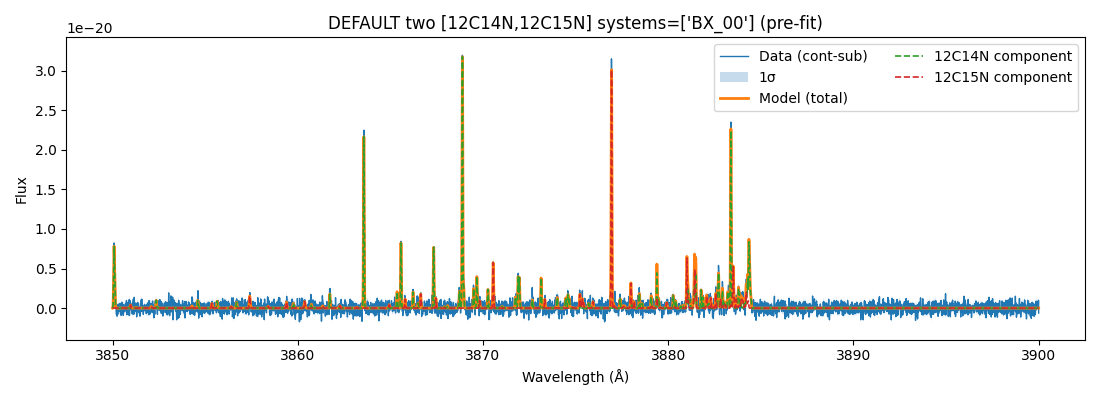

Number of iterations: 25000


100%|██████████| 250/250 [01:23<00:00,  3.00it/s]


##################################################
*** Best fit (no pruning) ***
logQ: -3.49536
T: 173.088
sigma: 0.0499955
logN_12C14N: 11.1222
logN_12C15N: 11.3506
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.3176
logQ: -3.8264 +/- 0.8183  [-4.6662, -3.0297]
T: 448.5746 +/- 257.2067  [207.3095, 721.7229]
sigma: 0.0499 +/- 0.0002  [0.0496, 0.0500]
logN_12C14N: 11.1276 +/- 0.0209  [11.1068, 11.1487]
logN_12C15N: 11.3518 +/- 0.0131  [11.3381, 11.3642]


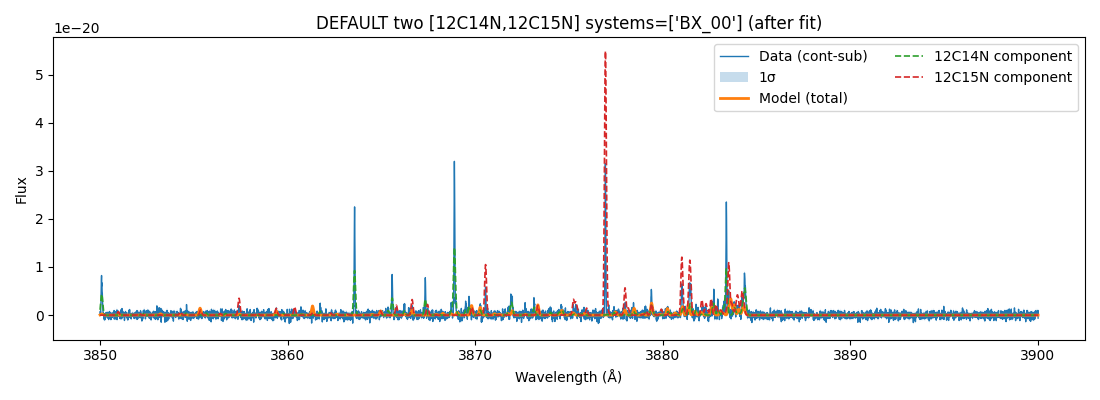

  fitted medians: {'logQ': -3.826439839867099, 'T': 448.57463400975223, 'sigma': 0.04986660651329506, 'logN_12C14N': 11.127563394345936, 'logN_12C15N': 11.35182634230262}


In [20]:

# B) DEFAULTS: two iso, different systems
for sys in systems_list:
    run_case(
        case_name=f"DEFAULT two [{iso1},{iso2}] systems={sys}",
        isotopologues=[iso1, iso2],
        use_defaults=True,
        pumping=pumping,
        window=window,
        systems=sys,
        user_linelists=None,
        do_fit=True,
        seed=11,
    )



CASE: DEFAULT three [12C14N,12C15N,13C14N] systems=None
  isotopologues = ['12C14N', '12C15N', '13C14N']
  use_defaults  = True
  systems       = None


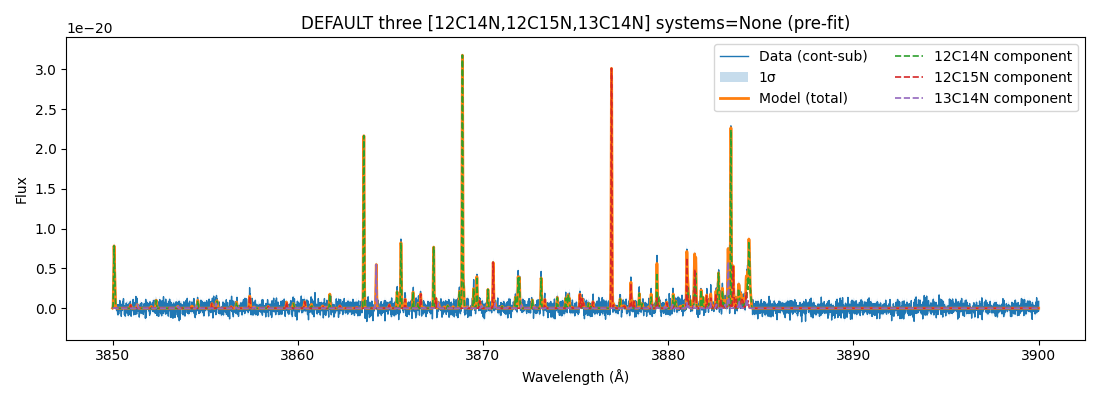

Number of iterations: 30000


 30%|███       | 76/250 [00:42<01:33,  1.86it/s]

In [ ]:

# C) DEFAULTS: three iso, different systems
for sys in systems_list:
    run_case(
        case_name=f"DEFAULT three [{iso1},{iso2},{iso3}] systems={sys}",
        isotopologues=[iso1, iso2, iso3],
        use_defaults=True,
        pumping=pumping,
        window=window,
        systems=sys,
        user_linelists=None,
        do_fit=True,
        seed=12,
    )
    break



CASE: USER three [12C14N,12C15N,13C14N]
  isotopologues = ['12C14N', '12C15N', '13C14N']
  use_defaults  = False
  systems       = None


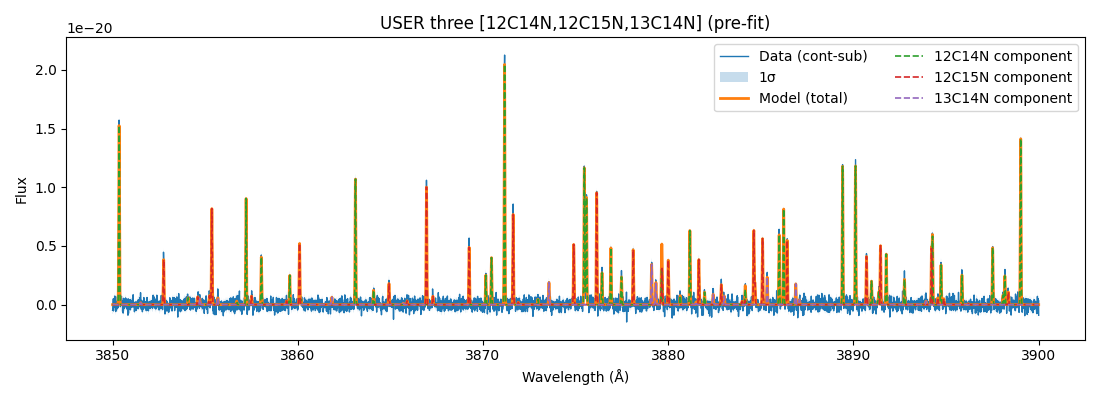

Number of iterations: 30000


100%|██████████| 250/250 [00:18<00:00, 13.72it/s]


##################################################
*** Best fit (no pruning) ***
logQ: -3.60151
T: 332.025
sigma: 0.0199585
logN_12C14N: 11.1002
logN_12C15N: 10.7003
logN_13C14N: 10.299
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.32680000000000003
logQ: -3.3663 +/- 0.8642  [-4.1501, -2.4217]
T: 380.4341 +/- 157.2433  [251.7453, 566.2319]
sigma: 0.0200 +/- 0.0001  [0.0199, 0.0201]
logN_12C14N: 11.1004 +/- 0.0025  [11.0978, 11.1029]
logN_12C15N: 10.7005 +/- 0.0042  [10.6960, 10.7044]
logN_13C14N: 10.3073 +/- 0.0163  [10.2896, 10.3222]


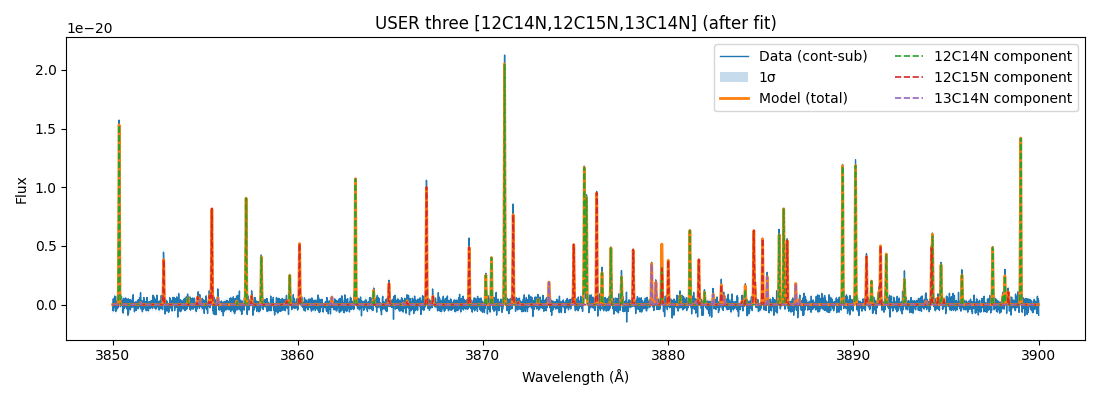

  fitted medians: {'logQ': -3.366261002927929, 'T': 380.43409488120653, 'sigma': 0.019973712614798873, 'logN_12C14N': 11.100402578649113, 'logN_12C15N': 10.700465917184703, 'logN_13C14N': 10.307319112381546}


(<pyfluor.fluorescence.FluorescenceModel at 0x11a4f3390>,
 {'param_keys': ['logQ',
   'T',
   'sigma',
   'logN_12C14N',
   'logN_12C15N',
   'logN_13C14N'],
  'median_params': {'logQ': -3.366261002927929,
   'T': 380.43409488120653,
   'sigma': 0.019973712614798873,
   'logN_12C14N': 11.100402578649113,
   'logN_12C15N': 10.700465917184703,
   'logN_13C14N': 10.307319112381546},
  'up_errors_params': {'logQ': 0.9445848494265876,
   'T': 185.79784408391538,
   'sigma': 9.864112720629065e-05,
   'logN_12C14N': 0.0025018351050736243,
   'logN_12C15N': 0.003911247737583778,
   'logN_13C14N': 0.01488973291930229},
  'low_errors_params': {'logQ': 0.7838542184652977,
   'T': 128.68880913705127,
   'sigma': 0.00010725994448128329,
   'logN_12C14N': 0.0025628312346839266,
   'logN_12C15N': 0.004438732949033408,
   'logN_13C14N': 0.017671410369343832},
  'samples_pruned': array([[-3.95531921e+00,  3.80040660e+02,  1.98916936e-02,
           1.11036644e+01,  1.07042318e+01,  1.03309914e+01],
   

In [ ]:



# F) USER line list: three iso
run_case(
    case_name=f"USER three [{iso1},{iso2},{iso3}]",
    isotopologues=[iso1, iso2, iso3],
    use_defaults=False,
    pumping=pumping,
    window=window,
    systems=None,  # ignored for user lists
    user_linelists=user_ll_3,
    do_fit=True,
    seed=22,
)



CASE: USER three [12C14N,12C15N,13C14N]
  isotopologues = ['12C14N', '12C15N', '13C14N']
  use_defaults  = False
  systems       = None


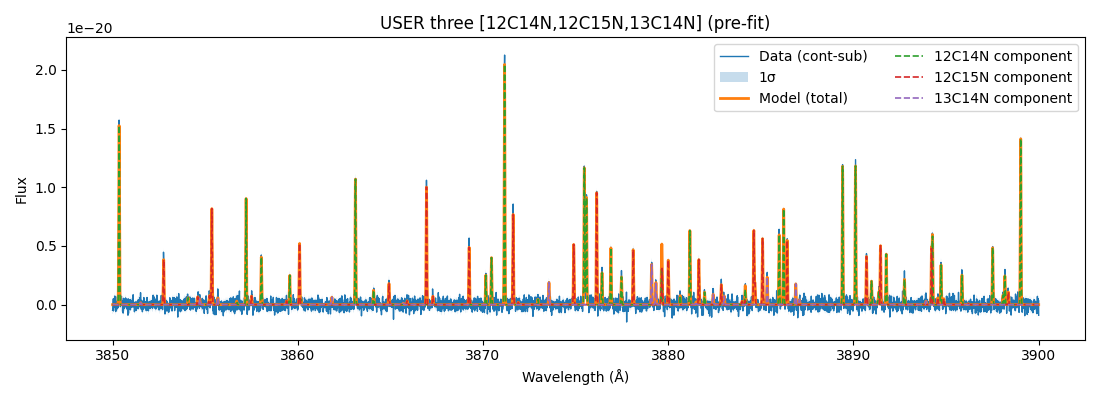

Number of iterations: 30000


 13%|█▎        | 33/250 [00:02<00:16, 13.32it/s]Traceback (most recent call last):
  File "/Users/baltasarluco/Desktop/pyfluor/.venv/lib/python3.13/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/baltasarluco/Desktop/pyfluor/.venv/lib/python3.13/site-packages/pyfluor/modeling.py", line 966, in lnprob
    ll = lnlike(theta)
  File "/Users/baltasarluco/Desktop/pyfluor/.venv/lib/python3.13/site-packages/pyfluor/modeling.py", line 958, in lnlike
    np.log(2.0 * np.pi * y_err_fit**2) +
    ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
 14%|█▎        | 34/250 [00:02<00:13, 15.52it/s]


emcee: Exception while calling your likelihood function:
  params: [-3.82463439e+00  6.76145148e+02  3.11036586e-02  1.12497811e+01
  1.07135523e+01  1.08592697e+01]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [ ]:



# F) USER line list: three iso
run_case(
    case_name=f"USER three [{iso1},{iso2},{iso3}]",
    isotopologues=[iso1, iso2, iso3],
    use_defaults=False,
    pumping=pumping,
    window=window,
    systems=None,  # ignored for user lists
    user_linelists=user_ll_3,
    do_fit=True,
    seed=22,
)
